# Inteligencia Artificial 25/26
# Trabajo Práctico: Planificación Automática Aplicada al Senku
## _Propuesta de trabajo del profesor Gabriel Chaves Benítez_
# Grado en Ingeniería Informática - Ingeniería del Software
# Universidad de Sevilla
#### _Mario Domínguez López y Elena Ramos Fernández_

## Introducción y Objetivos:

El tema del trabajo está centrado en el uso de algoritmos de búsqueda para la resolución de problemas de plpannificación, explorando tanto algoritmos basados en heurísticas como algoritmos estocásticos. Su objetivo principal es el ddiseño de un sistema para representar el juego del Senku mediante PDDL para dar con una secuencia de acciones que nos ofrezca una solución válida.

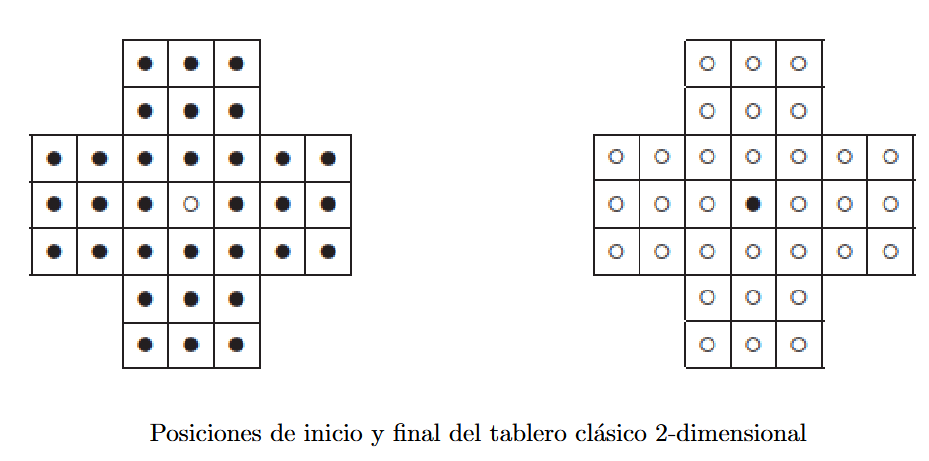

El Senku es un clásico juego de mesa consistente en un tablero con N piezas y un hueco disponible. El objetivo ddel juego es conseguir eliminar todas las piezas del tablero excepto una mediante saltos: el único movimiento legal del juego es escoger una de las piezas y pasar su posición a la de un hueco saltando una segunda pieza, que queda eliminada del tablero. Aunque existen varias versiones del juego, en este trabajo estudiaremos la versión en la que el objetivo final es que la última pieza que quede en el tablero quede en la posición del hueco original.

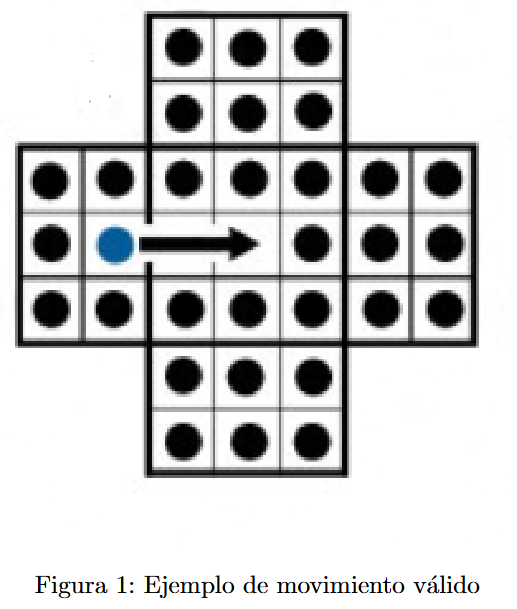

Además de la resolución del tablero básico, se busca la implementación de la heurística Función _Pagoda_, así como del algoritmo de búsqueda _Beam Search_.

Así, en este trabajo buscamos conseguir los siguientes objetivos específicos:
* Expresar el problema correctamente
* Diseñar un sistema capaz de usar PDDL que pueda solucionar el tablero básico
* Aumentar el número de tableros que se pueden solucionar aplicando el algoritmo de _Beam Search_ y la heurística _Pagoda_.

### Parte Común

In [2]:
#pip install unified-planning
#pip install up_fast_downward

In [8]:
from unified_planning.shortcuts import *
from unified_planning.io import PDDLWriter
from unified_planning.io import PDDLReader

In [4]:
dominio_senku = Problem('Senku')

### Definición del Dominio: Clases, Fluentes y Acciones

In [5]:
# Jerarquía de tipos de objetos

Cell = UserType('Cell')  # Lugar

dominio_senku.user_types.append(Cell)

In [6]:
# Predicados booleanos

# El predicado OCCUPIED representa que una casilla no está vacía
occupied = Fluent('OCCUPIED', BoolType(), x=Cell)
# El predicado CONNECTED indica si desde una casilla x se puede saltar a una z a través de una y
connected = Fluent('CONNECTED', BoolType(), x=Cell, y=Cell, z=Cell)
for fluente in [occupied, connected]:
    dominio_senku.add_fluent(fluente, default_initial_value=False)

In [7]:
# Esquemas de acciones

# La acción JUMP representa que saltamos de una celda x a una z a través de una y
jump = InstantaneousAction('JUMP', x=Cell, y=Cell, z=Cell)
x = jump.parameter('x')
y = jump.parameter('y')
z = jump.parameter('z')
for hecho in [connected(x, y, z), occupied(x), occupied(y), Not(occupied(z))]:
    jump.add_precondition(hecho)
for hecho in [occupied(x), occupied(y)]:
    jump.add_effect(hecho, False)
for hecho in [occupied(z)]:
    jump.add_effect(hecho, True)

dominio_senku.add_actions([jump])

In [8]:
print(dominio_senku)

problem name = Senku

types = [Cell]

fluents = [
  bool OCCUPIED[x=Cell]
  bool CONNECTED[x=Cell, y=Cell, z=Cell]
]

actions = [
  action JUMP(Cell x, Cell y, Cell z) {
    preconditions = [
      CONNECTED(x, y, z)
      OCCUPIED(x)
      OCCUPIED(y)
      (not OCCUPIED(z))
    ]
    effects = [
      OCCUPIED(x) := false
      OCCUPIED(y) := false
      OCCUPIED(z) := true
    ]
  }
]

objects = [
  Cell: []
]

initial fluents default = [
  bool OCCUPIED[x=Cell] := false
  bool CONNECTED[x=Cell, y=Cell, z=Cell] := false
]

initial values = [
]

goals = [
]




In [9]:
escritor_PDDL = PDDLWriter(dominio_senku)
escritor_PDDL.write_domain('dominio_senku.pddl')

In [10]:
def crea_instancia_senku(matrix):
    # Recibimos una matriz de None, ceros y unos dependiendo de si las celdas son transitables y si están vacías
    instancia = dominio_senku.clone()
    # Se añaden las celdas del problema conforme a la matriz recibida
    tipo_objeto = instancia.user_type('Cell')
    filas = len(matrix)
    columnas = len(matrix[0])
    celdas = [[None for x in range(columnas)]
          for y in range(filas)]
    for columna in range(columnas):
        for fila in range(filas):
            if matrix[fila][columna] != None:
                celdas[fila][columna] = (Object(f'C{fila}{columna}', tipo_objeto))
    for columna in range(columnas):
        for fila in range(filas):
            if celdas[fila][columna] != None:
                instancia.add_object(celdas[fila][columna])
    # Establecemos los fluentes
    ocupada = dominio_senku.fluent('OCCUPIED')
    conectadas = dominio_senku.fluent('CONNECTED')
    # Recorremos todas las celdas de la matriz.
    # Si no están vacías, lo añadimos al estado inicial y ponemos de objetivos que acaben vacías
    # Si es la celda vacía, lo contrario
    for columna in range(columnas):
        for fila in range(filas):
            if matrix[fila][columna] != None:
                celda = celdas[fila][columna]
                if matrix[fila][columna] == 0:
                    instancia.set_initial_value(ocupada(celda), False)
                    instancia.add_goal(ocupada(celda))
                elif matrix[fila][columna] == 1:
                    instancia.set_initial_value(ocupada(celda), True)
                    instancia.add_goal(Not(ocupada(celda)))
                # Añadimos las conexiones entre celdas (comprobando que ni ellas ni el hueco entre ellas sea None)
                if columna<(columnas-2) and matrix[fila][columna+1]!=None and matrix[fila][columna+2]!=None:
                    instancia.set_initial_value(conectadas(celdas[fila][columna],celdas[fila][columna+1],celdas[fila][columna+2]), True)
                    instancia.set_initial_value(conectadas(celdas[fila][columna+2],celdas[fila][columna+1],celdas[fila][columna]), True)
                if fila<(filas-2) and matrix[fila+1][columna]!=None and matrix[fila+2][columna]!=None:
                    instancia.set_initial_value(conectadas(celdas[fila][columna],celdas[fila+1][columna],celdas[fila+2][columna]), True)
                    instancia.set_initial_value(conectadas(celdas[fila+2][columna],celdas[fila+1][columna],celdas[fila][columna]), True)
    return instancia
    

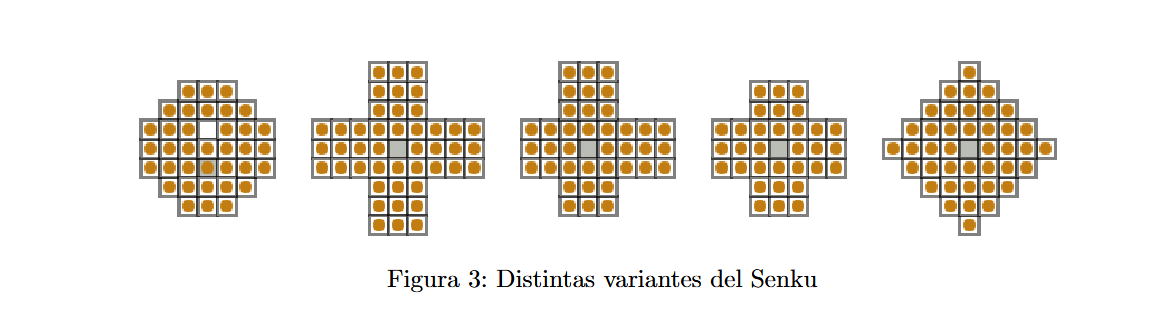

In [ ]:
matriz_var1 =[[None,None,1,1,1,None,None],
                 [None,1,1,1,1,1,None],
                    [1,1,1,0,1,1,1],
                    [1,1,1,1,1,1,1],
                    [1,1,1,1,1,1,1],
                 [None,1,1,1,1,1,None],
              [None,None,1,1,1,None,None]]

matriz_var2 =  [[None,None,None,1,1,1,None,None,None],
                [None,None,None,1,1,1,None,None,None],
                [None,None,None,1,1,1,None,None,None],
                         [1,1,1,1,1,1,1,1,1],
                         [1,1,1,1,0,1,1,1,1],
                         [1,1,1,1,1,1,1,1,1],
                [None,None,None,1,1,1,None,None,None],
                [None,None,None,1,1,1,None,None,None],
                [None,None,None,1,1,1,None,None,None]]

matriz_var3 =  [[None,None,1,1,1,None,None,None],
                [None,None,1,1,1,None,None,None],
                [None,None,1,1,1,None,None,None],
                      [1,1,1,1,1,1,1,1],
                      [1,1,1,0,1,1,1,1],
                      [1,1,1,1,1,1,1,1],
                [None,None,1,1,1,None,None,None],
                [None,None,1,1,1,None,None,None]]

matriz_var4 =[[None,None,1,1,1,None,None],
              [None,None,1,1,1,None,None],
                    [1,1,1,1,1,1,1],
                    [1,1,1,0,1,1,1],
                    [1,1,1,1,1,1,1],
              [None,None,1,1,1,None,None],
              [None,None,1,1,1,None,None]]

matriz_var5 =  [[None,None,None,None,1,None,None,None,None],
                   [None,None,None,1,1,1,None,None,None],
                      [None,None,1,1,1,1,1,None,None],
                         [None,1,1,1,1,1,1,1,None],
                            [1,1,1,1,0,1,1,1,1],
                         [None,1,1,1,1,1,1,1,None],
                      [None,None,1,1,1,1,1,None,None],
                   [None,None,None,1,1,1,None,None,None],    
                [None,None,None,None,1,None,None,None,None]]

In [12]:
def fluent_to_pddl(expr):

    s = str(expr)

    # Reemplazar "(" por espacio
    s = s.replace("(", " ")

    # Eliminar ")"
    s = s.replace(")", "")

    # Eliminar comas
    s = s.replace(",", "")

    s = s.replace("not","not(")
    if "not" in s:
         s+=")"
    # Añadir paréntesis externos
    return f"({s})"
def write_problem(filename, prob_name, domain_name, instancia):
        objects = instancia.objects(Cell)
        init = instancia.initial_values
        goals = instancia.goals
        with open(filename,'w') as f:
            # Cabecera
            f.write(f"(define (problem {prob_name}_prob) (:domain {domain_name})\n")
            # Objetos
            f.write("(:objects\n")
            obj_names = []
            for obj in objects:
                obj_names.append(str(obj))
            f.write("        "+" ".join(obj_names)+" - Cell)\n")
            # Init
            f.write("(:init\n")
            for fluent, value in init.items():
                if value.is_true():
                     f.write(f"         {fluent_to_pddl(fluent)}\n")
            f.write(")\n\n")
            # Goal
            f.write("(:goal (and\n")
            for goal in goals:
                f.write(f"      {fluent_to_pddl(goal)}\n")
            f.write("   )\n")
            # Final
            f.write("))")


In [13]:
instancia_var1 = crea_instancia_senku(matriz_var1)
instancia_var2 = crea_instancia_senku(matriz_var2)
instancia_var3 = crea_instancia_senku(matriz_var3)
instancia_var4 = crea_instancia_senku(matriz_var4)
instancia_var5 = crea_instancia_senku(matriz_var5)

In [14]:
write_problem("problemas/var1","var1", "Senku",instancia_var1)
write_problem("problemas/var2","var2", "Senku",instancia_var2)
write_problem("problemas/var3","var3", "Senku",instancia_var3)
write_problem("problemas/var4","var4", "Senku",instancia_var4)
write_problem("problemas/var5","var5", "Senku",instancia_var5)

In [15]:
planificador = OneshotPlanner(name='fast-downward')

NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 563 of `C:\Users\Mario\AppData\Roaming\Python\Python313\site-packages\unified_planning\shortcuts.py`, you are using the following planning engine:
  * Engine name: Fast Downward
  * Developers:  Uni Basel team and contributors (cf. https://github.com/aibasel/downward/blob/main/README.md)
  * Description: Fast Downward is a domain-independent classical planning system.



In [16]:
lector_PDDL = PDDLReader()
problema_senku_var1 = lector_PDDL.parse_problem('dominio_senku.pddl',
                                           'problemas/var1')
problema_senku_var2 = lector_PDDL.parse_problem('dominio_senku.pddl',
                                           'problemas/var2')
problema_senku_var3 = lector_PDDL.parse_problem('dominio_senku.pddl',
                                           'problemas/var3')
problema_senku_var4 = lector_PDDL.parse_problem('dominio_senku.pddl',
                                           'problemas/var4')
problema_senku_var5 = lector_PDDL.parse_problem('dominio_senku.pddl',
                                           'problemas/var5')

La parte básica del trabajo sólo requiere que se solucione la versión básica del problema, es decir, la Variante 4. Sin embargo, esta iteración de la búsqueda también es capaz de solucionar la variante 3:

In [17]:
resultado = planificador.solve(problema_senku_var3)
print(resultado)

status: SOLVED_SATISFICING
engine: Fast Downward
plan: SequentialPlan:
    jump(c41, c42, c43)
    jump(c62, c52, c42)
    jump(c50, c51, c52)
    jump(c30, c40, c50)
    jump(c32, c31, c30)
    jump(c12, c22, c32)
    jump(c14, c13, c12)
    jump(c02, c12, c22)
    jump(c04, c03, c02)
    jump(c32, c22, c12)
    jump(c02, c12, c22)
    jump(c33, c23, c13)
    jump(c34, c24, c14)
    jump(c14, c13, c12)
    jump(c12, c22, c32)
    jump(c53, c52, c51)
    jump(c36, c35, c34)
    jump(c56, c46, c36)
    jump(c50, c51, c52)
    jump(c55, c54, c53)
    jump(c74, c64, c54)
    jump(c53, c43, c33)
    jump(c33, c32, c31)
    jump(c37, c36, c35)
    jump(c34, c35, c36)
    jump(c57, c47, c37)
    jump(c30, c31, c32)
    jump(c37, c36, c35)
    jump(c35, c45, c55)
    jump(c72, c73, c74)
    jump(c44, c54, c64)
    jump(c74, c64, c54)
    jump(c55, c54, c53)
    jump(c53, c52, c51)
    jump(c32, c42, c52)
    jump(c51, c52, c53)
    jump(c63, c53, c43)


In [18]:
resultado = planificador.solve(problema_senku_var4)
print(resultado)

status: SOLVED_SATISFICING
engine: Fast Downward
plan: SequentialPlan:
    jump(c13, c23, c33)
    jump(c21, c22, c23)
    jump(c41, c31, c21)
    jump(c24, c23, c22)
    jump(c43, c42, c41)
    jump(c63, c53, c43)
    jump(c40, c41, c42)
    jump(c21, c22, c23)
    jump(c33, c23, c13)
    jump(c20, c30, c40)
    jump(c43, c42, c41)
    jump(c40, c41, c42)
    jump(c03, c13, c23)
    jump(c02, c12, c22)
    jump(c26, c25, c24)
    jump(c23, c24, c25)
    jump(c04, c14, c24)
    jump(c45, c44, c43)
    jump(c64, c54, c44)
    jump(c43, c42, c41)
    jump(c62, c52, c42)
    jump(c41, c42, c43)
    jump(c46, c36, c26)
    jump(c34, c44, c54)
    jump(c22, c32, c42)
    jump(c42, c43, c44)
    jump(c54, c44, c34)
    jump(c34, c24, c14)
    jump(c26, c25, c24)
    jump(c14, c24, c34)
    jump(c35, c34, c33)


### Parte de la Convocatoria de Junio

En esta parte del trabajo implementamos de forma manual el parseo de los archivos PDDL y el uso de _Beam Search_, así como la heurística _Pagoda_.
Para permitir el uso de nuestro algoritmo de búsqueda de forma manual, debemos definir una forma de representar estados del problema de forma eficiente y comparable. Nos hemos dedidido por el uso de frozenset, sets inmutables muy eficientes.

Los estados representarán las casillas que se encuentran ocupadas, siendo el inicial la lista de las casillas con estado inicial OCCUPIED. Así, conforme avancemos y realicemos movimientos en el tablero los estados serán más pequeños, ayudándonos a hacer más eficiente la búsqueda en lugar de hacer un diccionario de casillas libres y ocupadas, por ejemplo, que resultaría muy costoso.

Asimismo, guardaremos una lista de movimientos posibles que almacene un triplete de celdas entre las que se puedan realizar movimientos.

Así, tenemos la función que recibe como entradas los ficheros PDDL del dominio y del problema y nos da como salida el estado inicial del problema, el objetivo al que buscamos llegar y todos los movimientos posibles en el tablero (es decir, las celdas que están conectadas independientemente de si podemos realizar el movimiento ahora mismo o no): 

In [1]:
from unified_planning.shortcuts import *
from unified_planning.io import PDDLWriter
from unified_planning.io import PDDLReader
Cell = UserType('Cell')  # Lugar

In [82]:
def parseo_problema_senku(fichero_dominio, fichero_problema):
    lector = PDDLReader()
    problema = lector.parse_problem(fichero_dominio, fichero_problema)
    objetos = problema.objects(Cell)
    iniciales = problema.initial_values
    goals = problema.goals
    #para el estado inicial:
    estado_inicial = set()
    movimientos = []
    for fluent, value in iniciales.items():
        if value.is_true():
            texto = str(fluent)
            if texto.lower().startswith("occupied"):
                celda = texto[9:-1]
                estado_inicial.add(celda)
            elif texto.lower().startswith("connected"):
                interior = texto[10:-1]
                partes = interior.split(",")
                x = partes[0].strip()
                y = partes[1].strip()
                z = partes[2].strip()
                movimientos.append((x,y,z))
    estado_inicial = frozenset(estado_inicial)

    estado_objetivo = set()
    for goal in goals:
        textoANDS = str(goal)
        textos=textoANDS.split('and')
        for texto in textos:
            if texto.lstrip().lower().startswith("occupied"):
                celda = texto[9:-1]
                celda = celda.replace("(","").replace(")","").lstrip()
                estado_objetivo.add(celda)
    estado_objetivo = frozenset(estado_objetivo)
    return estado_inicial, estado_objetivo, movimientos

Para poder aplicar el _Beam Search_ necesitaremos primero ser capaces de generar posibles sucesores a partir de un estado (en este caso, a partir del estado inicial). Conseguimos esto recorriendo todos los movimientos posibles del tablero y comprobando cuáles podemos realizar con las condiciones del estado actual. 
Al aplicar un movimiento devolveremos un estado en el que hemos quitado del set las primeras dos celdas del movimiento y hemos añadido la última, haciendo efectivamente el paso de la ficha de una celda a otra eliminando la ficha de la celda intermedia.

In [75]:
def movimientos_posibles(estado, movimientos):
    movs = []
    for (x, y, z) in movimientos:
        if x in estado and y in estado and z not in estado:
            movs.append((x, y, z))
    return movs
def aplicar_movimiento(estado, movimiento):
    x, y, z = movimiento
    nuevo = set(estado)

    nuevo.remove(x)
    nuevo.remove(y)
    nuevo.add(z)
    return frozenset(nuevo)



Se me acaba el cerebro para explicar cosas, mañana lo hago mejor, pero tenemos la función para aplicar la heurística pagoda (que depende de que hayamos generado ya la pagoda, no se como lo vamos a hacer la vd) y la función que comprueba si un estado es el estado objetivo o hay que seguir aplicando el algoritmo.

In [120]:
def heuristic_pagoda(estado, pagoda):
    return sum(pagoda[c] for c in estado)

def es_objetivo(estado, goal_state):
    return estado == goal_state

Algoritmo beam search, no se si esta bien implementado para nada, hay que darle un repaso grande porque no lo he probado. La idea es tener un plan (lista de acciones para llegar al estado), un set de estados visitados y un haz (un beam, que es una lista de tripletes de heurística, estado actual y el plan hasta el momento).

### No estoy nada seguro de que haya aplicado bien la heuristica pagoda, hay que darle un repaso goldo porque ya tengo el cerebro como si hubiera usado mi craneo pa freir boquerones.

Mientras no se encuentre solución, se generan nuevos posibles estados conforme a los movimientos posibles y creamos una lista de tripletes NO VISITADOS que ordenamos según la heurística pagoda.

Nos quedamos con los beta mejores tripletes según pagoda y los añadimos al haz. Como es búsqueda en anchura y con heurística no hace falta que lo reordenemos, simplemente pasamos al siguiente nivel y palante. La idea es que tengamos beta estados potenciales, y de cada uno calculamos todos los movimientos posibles y los estados resultantes de cada uno. Una vez hemos calculado todo eso nos quedamos con los beta mejores y tenemos nuestro nuevo haz.

Si después de recorrer todas las acciones posibles no se generan más y nos quedamos sin acciones, devolvemos None (no hemos encontrado solución).

In [169]:
def crear_pagoda(movimientos, casilla_obj):
    # Pagoda trivial, todas las casillas valen 1, no me preguntes como hacer una mejor porque no se me ocurre ahora mismo.
    # Si seguimos los ejemplos, es cuestion de asignar 0 a todas las filas impares, y en las filas pares asignar 1 a todas las columnas pares.
    celdas = set()

    matriz_dist=[[None,None,0,1,0,None,None],
                 [None,None,1,2,1,None,None],
                       [0,1,2,3,2,1,0],
                       [1,2,3,4,3,2,1],
                       [0,1,2,3,2,1,0],
                 [None,None,1,2,1,None,None],
                 [None,None,0,1,0,None,None]]
    
    
    matriz_alfa=[[None,None,4,3,4,None,None],
                 [None,None,3,2,3,None,None],
                       [4,3,2,1,2,3,4],
                       [3,2,1,0,1,2,3],
                       [4,3,2,1,2,3,4],
                 [None,None,3,2,3,None,None],
                 [None,None,4,3,4,None,None]]
    
    matriz_hazs=[[None,None,2,1,2,None,None],
                 [None,None,1,3,1,None,None],
                       [2,1,2,1,2,1,2],
                       [1,3,1,4,1,3,1],
                       [2,1,2,1,2,1,2],
                 [None,None,1,3,1,None,None],
                 [None,None,2,1,2,None,None]]
    
    matriz_zebr=[[None,None,0,0,1,None,None],
                 [None,None,0,1,0,None,None],
                       [1,0,1,0,1,0,1],
                       [0,1,0,0,0,1,0],
                       [1,0,1,0,1,0,1],
                 [None,None,0,1,0,None,None],
                 [None,None,1,0,1,None,None]]
    
    matriz_orig=[[None,None,1,0,1,None,None],
                 [None,None,0,0,0,None,None],
                       [1,0,1,0,1,0,1],
                       [0,0,0,0,0,0,0],
                       [1,0,1,0,1,0,1],
                 [None,None,0,0,0,None,None],
                 [None,None,1,0,1,None,None]]
    for x, y, z in movimientos:
        celdas.add(x)
        celdas.add(y)
        celdas.add(z)
    pagoda = {}
    col_obj = int(casilla_obj[-1])
    fil_obj = int(casilla_obj[-2])
    for c in celdas:
        col_celda = int(c[-1])
        fil_celda = int(c[-2])
        pagoda[c] =abs(col_obj-col_celda)+abs(fil_obj-fil_celda)
        #if columna_celda%2==0 and fila_celda%2==0:
        #    pagoda[c] = 1
        #else:
        #    pagoda[c] = 0
    return pagoda

In [ ]:

def beam_search(estado_inicial,goal_state,movimientos,beta):
    plan = []
    pagoda = crear_pagoda(movimientos, next(iter(goal_state.copy())))
    visitados = set()
    visitados.add(estado_inicial)

    #triplete heuristica, estado actual (inicial) y plan (vacío, porque inicial)
    beam = [(heuristic_pagoda(estado_inicial, pagoda),estado_inicial,plan)]

    #mientras el beam no esté vacío
    while beam:
        visitados = set()
        candidatos = []
        for heur, estado, plan in beam:
            aplicables = movimientos_posibles(estado,movimientos)
            for accion in aplicables:
                
                nuevo_estado = aplicar_movimiento(estado,accion)
                if nuevo_estado not in visitados:
                    visitados.add(nuevo_estado)
                    
                    nuevo_plan = plan + [accion]
                    h = heuristic_pagoda(nuevo_estado,pagoda)
                    if es_objetivo(nuevo_estado, goal_state):
                        return nuevo_plan
                    candidatos.append((h,nuevo_estado,nuevo_plan))

        candidatos.sort(key=lambda x: x[0])

        beam = candidatos[:beta]
    return None

No funca hihihaha, hay que darle una vuelta que te cagas, sobre todo a la logica del beam, pero creo que la estructura basica la tenemos.

In [144]:
estado_inicial, goal_state, movimientos = parseo_problema_senku("dominio_senku.pddl",
                                                                "problemas/var4")
#No parece muy optimizado, lo mismo trabajar con grafos es mas rapido
#Aparte no parece que la heuristica funcione muy bien y acaba quedanddose sin opciones
#Tiene pinta de que puede ayudar usar numeros negativos para los bordes

plan = beam_search(estado_inicial,
                   goal_state,
                   movimientos,
                   beta=50)
print("PLAN ENCONTRADO:")
print(plan)

[(88, frozenset({'c35', 'c42', 'c43', 'c12', 'c02', 'c36', 'c45', 'c54', 'c44', 'c46', 'c25', 'c13', 'c63', 'c62', 'c23', 'c04', 'c64', 'c34', 'c31', 'c52', 'c20', 'c26', 'c40', 'c32', 'c03', 'c14', 'c24', 'c53', 'c41', 'c30', 'c21', 'c22'}), [])]
PLAN ENCONTRADO:
[('c31', 'c32', 'c33'), ('c12', 'c22', 'c32'), ('c24', 'c23', 'c22'), ('c04', 'c14', 'c24'), ('c25', 'c24', 'c23'), ('c45', 'c35', 'c25'), ('c26', 'c25', 'c24'), ('c32', 'c22', 'c12'), ('c02', 'c12', 'c22'), ('c52', 'c42', 'c32'), ('c40', 'c41', 'c42'), ('c43', 'c44', 'c45'), ('c64', 'c54', 'c44'), ('c45', 'c44', 'c43'), ('c20', 'c30', 'c40'), ('c62', 'c63', 'c64'), ('c46', 'c36', 'c26'), ('c23', 'c24', 'c25'), ('c26', 'c25', 'c24'), ('c21', 'c22', 'c23'), ('c43', 'c42', 'c41'), ('c40', 'c41', 'c42'), ('c23', 'c24', 'c25'), ('c03', 'c13', 'c23'), ('c32', 'c42', 'c52'), ('c52', 'c53', 'c54'), ('c64', 'c54', 'c44'), ('c44', 'c34', 'c24'), ('c33', 'c23', 'c13'), ('c25', 'c24', 'c23'), ('c13', 'c23', 'c33')]


In [171]:
estado_inicial, goal_state, movimientos = parseo_problema_senku("dominio_senku.pddl",
                                                                "problemas/var1")
plan = beam_search(estado_inicial,
                   goal_state,
                   movimientos,
                   beta=150000)
print("PLAN ENCONTRADO:")
print(plan)

PLAN ENCONTRADO:
None


In [156]:
estado_inicial, goal_state, movimientos = parseo_problema_senku("dominio_senku.pddl",
                                                                "problemas/var2")
plan = beam_search(estado_inicial,
                   goal_state,
                   movimientos,
                   beta=5000)
print("PLAN ENCONTRADO:")
print(plan)

[(144, frozenset({'c35', 'c38', 'c84', 'c42', 'c83', 'c48', 'c43', 'c36', 'c45', 'c54', 'c47', 'c57', 'c56', 'c46', 'c25', 'c13', 'c74', 'c63', 'c05', 'c33', 'c73', 'c75', 'c85', 'c23', 'c04', 'c64', 'c34', 'c31', 'c52', 'c37', 'c50', 'c40', 'c32', 'c58', 'c03', 'c14', 'c24', 'c55', 'c53', 'c65', 'c41', 'c30', 'c51', 'c15'}), [])]
PLAN ENCONTRADO:
[('c42', 'c43', 'c44'), ('c23', 'c33', 'c43'), ('c03', 'c13', 'c23'), ('c31', 'c32', 'c33'), ('c51', 'c41', 'c31'), ('c30', 'c31', 'c32'), ('c15', 'c14', 'c13'), ('c35', 'c25', 'c15'), ('c05', 'c15', 'c25'), ('c37', 'c36', 'c35'), ('c57', 'c47', 'c37'), ('c38', 'c37', 'c36'), ('c55', 'c56', 'c57'), ('c58', 'c57', 'c56'), ('c75', 'c65', 'c55'), ('c73', 'c74', 'c75'), ('c85', 'c75', 'c65'), ('c50', 'c40', 'c30'), ('c33', 'c32', 'c31'), ('c30', 'c31', 'c32'), ('c83', 'c84', 'c85'), ('c55', 'c65', 'c75'), ('c85', 'c75', 'c65'), ('c13', 'c23', 'c33'), ('c53', 'c63', 'c73'), ('c65', 'c64', 'c63'), ('c73', 'c63', 'c53'), ('c34', 'c24', 'c14'), ('c04

In [153]:
estado_inicial, goal_state, movimientos = parseo_problema_senku("dominio_senku.pddl",
                                                                "problemas/var3")
plan = beam_search(estado_inicial,
                   goal_state,
                   movimientos,
                   beta=500)
print("PLAN ENCONTRADO:")
print(plan)

[(116, frozenset({'c35', 'c42', 'c12', 'c02', 'c72', 'c36', 'c45', 'c54', 'c47', 'c57', 'c56', 'c44', 'c46', 'c13', 'c74', 'c63', 'c33', 'c73', 'c62', 'c23', 'c04', 'c64', 'c34', 'c31', 'c52', 'c37', 'c50', 'c40', 'c32', 'c03', 'c14', 'c24', 'c55', 'c53', 'c41', 'c30', 'c51', 'c22'}), [])]
PLAN ENCONTRADO:
[('c23', 'c33', 'c43'), ('c35', 'c34', 'c33'), ('c37', 'c36', 'c35'), ('c14', 'c24', 'c34'), ('c12', 'c13', 'c14'), ('c04', 'c14', 'c24'), ('c02', 'c03', 'c04'), ('c34', 'c24', 'c14'), ('c04', 'c14', 'c24'), ('c56', 'c46', 'c36'), ('c36', 'c35', 'c34'), ('c54', 'c55', 'c56'), ('c57', 'c56', 'c55'), ('c52', 'c53', 'c54'), ('c50', 'c51', 'c52'), ('c55', 'c54', 'c53'), ('c74', 'c64', 'c54'), ('c53', 'c52', 'c51'), ('c72', 'c62', 'c52'), ('c51', 'c52', 'c53'), ('c32', 'c42', 'c52'), ('c30', 'c31', 'c32'), ('c40', 'c41', 'c42'), ('c44', 'c45', 'c46'), ('c47', 'c46', 'c45'), ('c24', 'c34', 'c44'), ('c53', 'c52', 'c51'), ('c73', 'c63', 'c53'), ('c54', 'c53', 'c52'), ('c51', 'c52', 'c53'), (

In [174]:
estado_inicial, goal_state, movimientos = parseo_problema_senku("dominio_senku.pddl",
                                                                "problemas/var5")
plan = beam_search(estado_inicial,
                   goal_state,
                   movimientos,
                   beta=1500)
print("PLAN ENCONTRADO:")
print(plan)

PLAN ENCONTRADO:
None
